# Notebook 03 — Forme du smile de volatilité (Expérience E3)

**PFE MMF ING3 — CY Tech, 2025-2026**  
Auteurs : Corentin Stephan, Hugo Landron  
Encadrants : Y. Aktar, I. Kortchemski

---

## Objectif

Ce notebook implémente l'**expérience E3** : étude de la forme du smile de volatilité implicite
généré par le modèle de Merton sous l'effet des paramètres $(\lambda, \delta, \mu_J)$.

### Rappel

La **volatilité implicite Black-Scholes** $\sigma_{\text{imp}}(K, T)$ est définie comme la valeur
de $\sigma$ telle que :

$$C_{\text{BS}}(S_0, K, T, r, \sigma_{\text{imp}}) = C_{\text{Merton}}(S_0, K, T)$$

Elle est calculée par inversion numérique (méthode de Brent). Si Black-Scholes était exact,
$\sigma_{\text{imp}}$ serait constante — c'est le **smile** qui révèle la présence de sauts.

### Propriétés qualitatives attendues (Cont & Tankov, 2004, Ch. 11)
- $\lambda$ contrôle la **hauteur** du smile
- $\delta$ contrôle la **largeur** du smile  
- $\mu_J$ contrôle l'**asymétrie** (skew) : $\mu_J < 0$ produit un skew négatif

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from merton_calib.implied_vol import merton_implied_vol
from merton_calib.pricing import black_scholes_call, merton_call_analytic

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11,
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})
os.makedirs('../figures', exist_ok=True)
print('Imports OK')

Imports OK


## 1. Paramètres de base et grille de strikes

In [2]:
# Paramètres de base
S0      = 100.0
r       = 0.02     # Taux sans risque
sigma   = 0.15     # Volatilité diffusive
lambda_ = 1.0      # Intensité de référence
mu_J    = -0.10    # Saut moyen de référence
delta   = 0.12     # Écart-type des sauts de référence

# Grille de moneyness K/S0
moneyness_grid = np.linspace(0.75, 1.25, 51)
K_grid = S0 * moneyness_grid

# Maturités étudiées
maturities = [0.25, 0.5, 1.0, 2.0]

print(f'Paramètres de base : sigma={sigma}, lambda={lambda_}, mu_J={mu_J}, delta={delta}')
print(f'Grille K/S0 : [{moneyness_grid[0]:.2f}, {moneyness_grid[-1]:.2f}], {len(K_grid)} points')

def compute_smile(K_grid, T, r, sigma, lambda_, mu_J, delta):
    """Calcule le smile de volatilité implicite sur la grille K_grid."""
    vols = []
    for K in K_grid:
        iv = merton_implied_vol(S0, K, T, r, sigma, lambda_, mu_J, delta)
        vols.append(iv * 100 if not np.isnan(iv) else np.nan)  # en %
    return np.array(vols)

Paramètres de base : sigma=0.15, lambda=1.0, mu_J=-0.1, delta=0.12
Grille K/S0 : [0.75, 1.25], 51 points


## 2. Smile de référence par maturité

On commence par tracer le smile de Merton pour les 4 maturités avec les paramètres de référence.

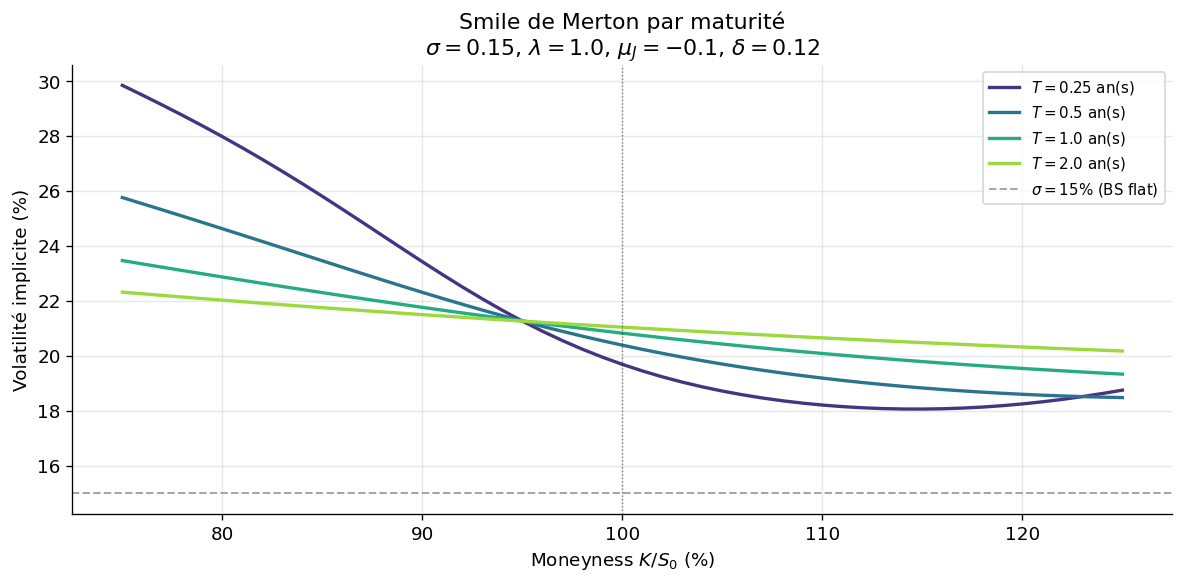

In [3]:
colors_T = cm.viridis(np.linspace(0.15, 0.85, len(maturities)))

fig, ax = plt.subplots(figsize=(10, 5))

for T, col in zip(maturities, colors_T):
    smile = compute_smile(K_grid, T, r, sigma, lambda_, mu_J, delta)
    ax.plot(moneyness_grid * 100, smile, '-', color=col, linewidth=2,
            label=f'$T = {T}$ an(s)')

ax.axhline(sigma * 100, color='gray', linestyle='--', linewidth=1.2,
           alpha=0.7, label=f'$\\sigma = {sigma*100:.0f}\\%$ (BS flat)')
ax.axvline(100, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Moneyness $K/S_0$ (%)')
ax.set_ylabel('Volatilité implicite (%)')
ax.set_title(
    f'Smile de Merton par maturité\n'
    f'$\\sigma={sigma}$, $\\lambda={lambda_}$, $\\mu_J={mu_J}$, $\\delta={delta}$'
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../figures/E3_smile_par_maturite.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Impact de l'intensité $\lambda$

**Propriété attendue** : $\lambda$ contrôle la hauteur du smile. Plus $\lambda$ est élevé,
plus le smile est prononcé. Pour $\lambda = 0$, on retrouve le smile plat de Black-Scholes.

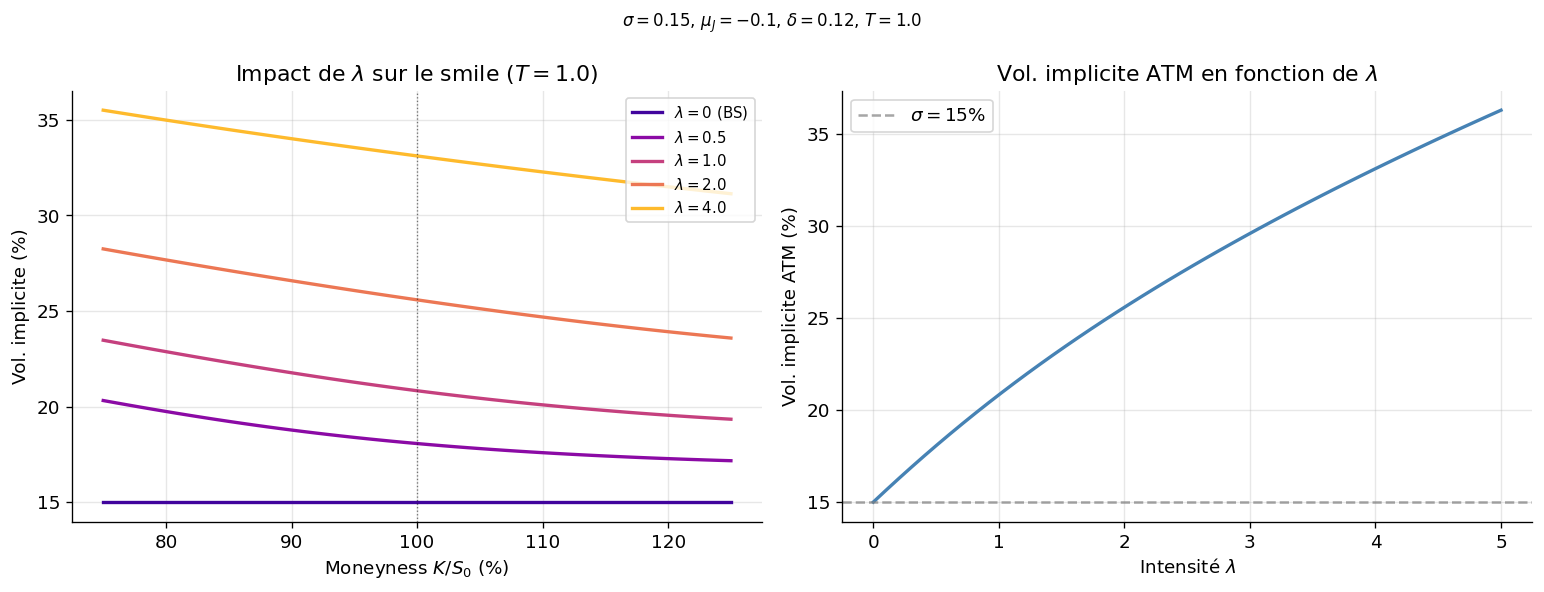

In [4]:
T_ref = 1.0  # Maturité de référence

lambda_values = [0.0, 0.5, 1.0, 2.0, 4.0]
colors_l = cm.plasma(np.linspace(0.1, 0.85, len(lambda_values)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Smile en vol implicite ────────────────────────────────────────────────────
ax = axes[0]
for lam, col in zip(lambda_values, colors_l):
    smile = compute_smile(K_grid, T_ref, r, sigma, lam, mu_J, delta)
    label = f'$\\lambda = {lam}$' if lam > 0 else f'$\\lambda = 0$ (BS)'
    ax.plot(moneyness_grid * 100, smile, '-', color=col, linewidth=2, label=label)

ax.axvline(100, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Moneyness $K/S_0$ (%)')
ax.set_ylabel('Vol. implicite (%)')
ax.set_title(f'Impact de $\\lambda$ sur le smile ($T={T_ref}$)')
ax.legend(fontsize=9)

# ── ATM vol implicite vs. lambda ──────────────────────────────────────────────
ax2 = axes[1]
lambda_fine = np.linspace(0, 5, 50)
atm_vols = []
for lam in lambda_fine:
    iv = merton_implied_vol(S0, S0, T_ref, r, sigma, lam, mu_J, delta)
    atm_vols.append(iv * 100 if not np.isnan(iv) else np.nan)
ax2.plot(lambda_fine, atm_vols, 'steelblue', linewidth=2)
ax2.axhline(sigma * 100, color='gray', linestyle='--', alpha=0.7, label=f'$\\sigma={sigma*100:.0f}\\%$')
ax2.set_xlabel('Intensité $\\lambda$')
ax2.set_ylabel('Vol. implicite ATM (%)')
ax2.set_title('Vol. implicite ATM en fonction de $\\lambda$')
ax2.legend()

plt.suptitle(f'$\\sigma={sigma}$, $\\mu_J={mu_J}$, $\\delta={delta}$, $T={T_ref}$', fontsize=10)
plt.tight_layout()
plt.savefig('../figures/E3_impact_lambda.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Impact de l'écart-type des sauts $\delta$

**Propriété attendue** : $\delta$ contrôle la largeur du smile. Un $\delta$ plus grand
produit un smile plus large (queues plus épaisses dans la distribution des rendements).

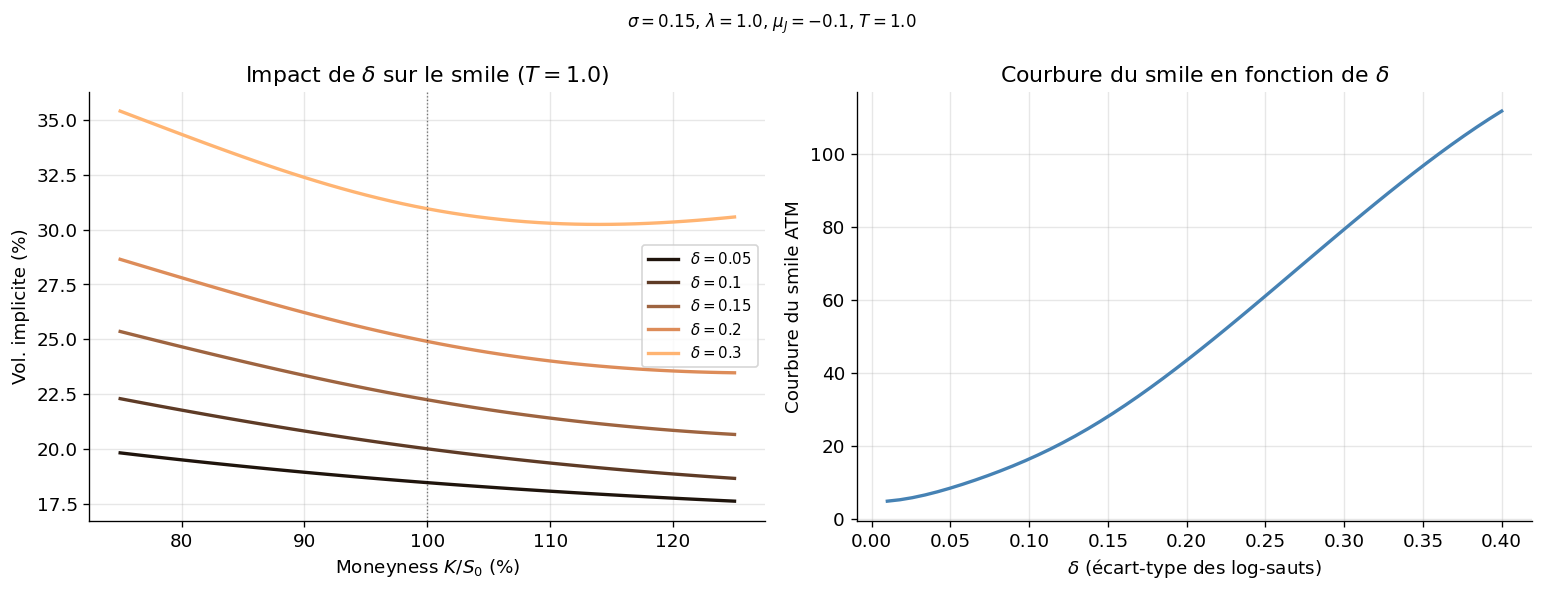

In [5]:
delta_values = [0.05, 0.10, 0.15, 0.20, 0.30]
colors_d = cm.copper(np.linspace(0.1, 0.9, len(delta_values)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for dlt, col in zip(delta_values, colors_d):
    smile = compute_smile(K_grid, T_ref, r, sigma, lambda_, mu_J, dlt)
    ax.plot(moneyness_grid * 100, smile, '-', color=col, linewidth=2,
            label=f'$\\delta = {dlt}$')
ax.axvline(100, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Moneyness $K/S_0$ (%)')
ax.set_ylabel('Vol. implicite (%)')
ax.set_title(f'Impact de $\\delta$ sur le smile ($T={T_ref}$)')
ax.legend(fontsize=9)

# Courbure ATM (approximation de la convexité du smile)
ax2 = axes[1]
idx_atm = np.argmin(np.abs(moneyness_grid - 1.0))
delta_fine = np.linspace(0.01, 0.40, 50)
curvatures = []
for dlt in delta_fine:
    smile = compute_smile(K_grid, T_ref, r, sigma, lambda_, mu_J, dlt)
    if not np.all(np.isnan(smile)):
        # Courbure = dérivée seconde au ATM (différence finie)
        curv = (smile[idx_atm+2] - 2*smile[idx_atm] + smile[idx_atm-2]) / (moneyness_grid[2] - moneyness_grid[0])**2
        curvatures.append(curv)
    else:
        curvatures.append(np.nan)
ax2.plot(delta_fine, curvatures, 'steelblue', linewidth=2)
ax2.set_xlabel('$\\delta$ (écart-type des log-sauts)')
ax2.set_ylabel('Courbure du smile ATM')
ax2.set_title('Courbure du smile en fonction de $\\delta$')

plt.suptitle(f'$\\sigma={sigma}$, $\\lambda={lambda_}$, $\\mu_J={mu_J}$, $T={T_ref}$', fontsize=10)
plt.tight_layout()
plt.savefig('../figures/E3_impact_delta.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Impact de la moyenne des sauts $\mu_J$

**Propriété attendue** : $\mu_J$ contrôle l'asymétrie (skew) du smile.
- $\mu_J < 0$ : sauts négatifs dominants → skew négatif (observé sur les indices d'actions)
- $\mu_J = 0$ : smile symétrique
- $\mu_J > 0$ : skew positif

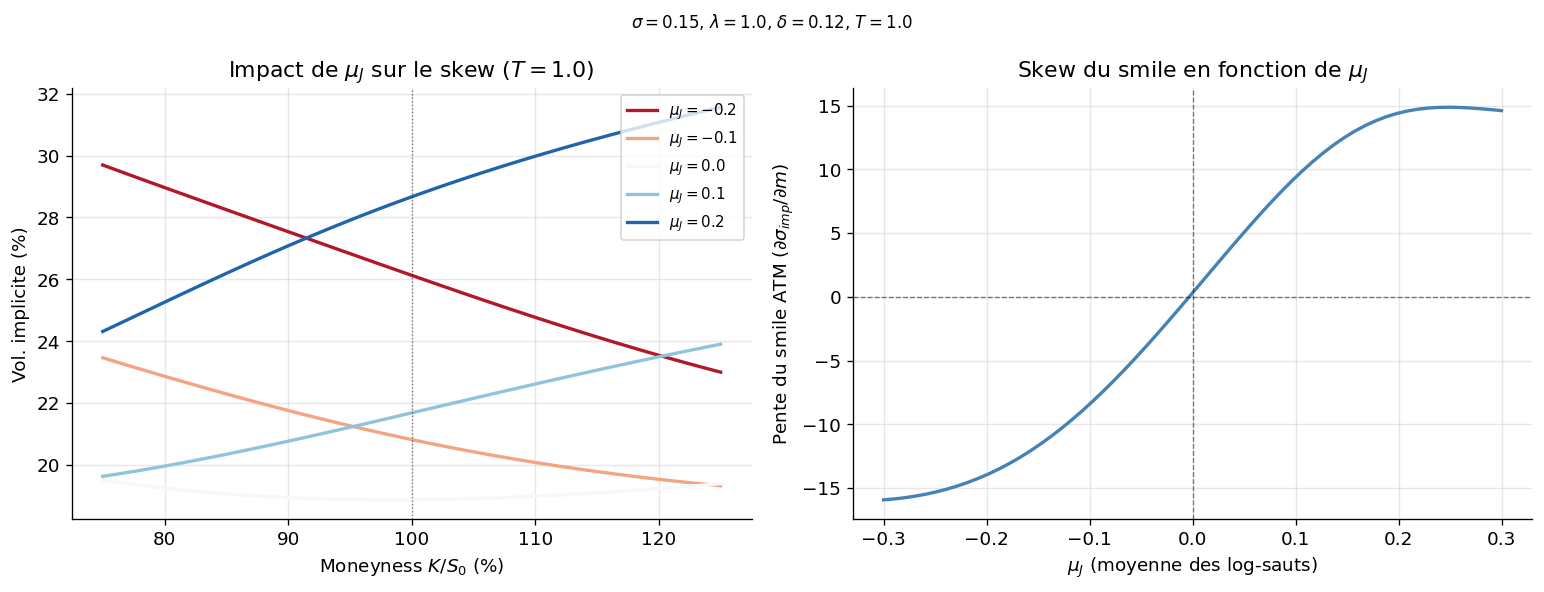

In [6]:
muJ_values = [-0.20, -0.10, 0.0, 0.10, 0.20]
colors_m = cm.RdBu(np.linspace(0.1, 0.9, len(muJ_values)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for mj, col in zip(muJ_values, colors_m):
    smile = compute_smile(K_grid, T_ref, r, sigma, lambda_, mj, delta)
    ax.plot(moneyness_grid * 100, smile, '-', color=col, linewidth=2,
            label=f'$\\mu_J = {mj}$')
ax.axvline(100, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Moneyness $K/S_0$ (%)')
ax.set_ylabel('Vol. implicite (%)')
ax.set_title(f'Impact de $\\mu_J$ sur le skew ($T={T_ref}$)')
ax.legend(fontsize=9)

# Skew ATM (pente de la vol implicite en ATM)
ax2 = axes[1]
muJ_fine = np.linspace(-0.30, 0.30, 60)
skews = []
for mj in muJ_fine:
    smile = compute_smile(K_grid, T_ref, r, sigma, lambda_, mj, delta)
    if not np.all(np.isnan(smile)):
        # Skew = pente de la vol implicite au ATM (différence centrée)
        sk = (smile[idx_atm+1] - smile[idx_atm-1]) / (moneyness_grid[idx_atm+1] - moneyness_grid[idx_atm-1])
        skews.append(sk)
    else:
        skews.append(np.nan)
ax2.plot(muJ_fine, skews, 'steelblue', linewidth=2)
ax2.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.set_xlabel('$\\mu_J$ (moyenne des log-sauts)')
ax2.set_ylabel('Pente du smile ATM ($\\partial \\sigma_{imp} / \\partial m$)')
ax2.set_title('Skew du smile en fonction de $\\mu_J$')

plt.suptitle(f'$\\sigma={sigma}$, $\\lambda={lambda_}$, $\\delta={delta}$, $T={T_ref}$', fontsize=10)
plt.tight_layout()
plt.savefig('../figures/E3_impact_muJ.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Surface de volatilité implicite (nappe 3D)

On trace la surface complète $\sigma_{\text{imp}}(K/S_0, T)$ pour visualiser la structure
par terme du smile de Merton.

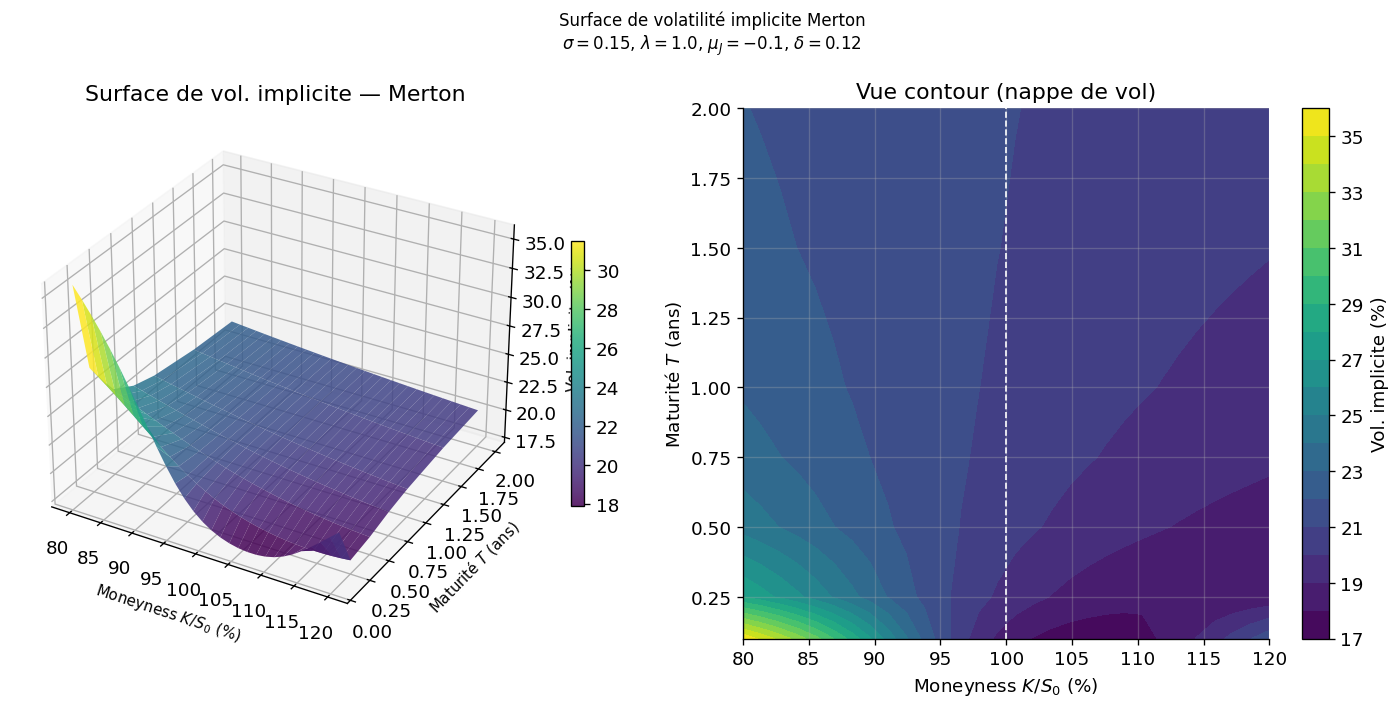

In [7]:
maturities_3d = np.array([0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0])
moneyness_3d  = np.linspace(0.80, 1.20, 30)
K_3d = S0 * moneyness_3d

# Construction de la surface
surface = np.zeros((len(maturities_3d), len(K_3d)))
for i, T in enumerate(maturities_3d):
    for j, K in enumerate(K_3d):
        iv = merton_implied_vol(S0, K, T, r, sigma, lambda_, mu_J, delta)
        surface[i, j] = iv * 100 if not np.isnan(iv) else np.nan

M, T_mesh = np.meshgrid(moneyness_3d * 100, maturities_3d)

fig = plt.figure(figsize=(12, 6))

# Vue 3D
ax3d = fig.add_subplot(121, projection='3d')
surf = ax3d.plot_surface(M, T_mesh, surface, cmap='viridis', alpha=0.85,
                          edgecolor='none')
ax3d.set_xlabel('Moneyness $K/S_0$ (%)', fontsize=9)
ax3d.set_ylabel('Maturité $T$ (ans)', fontsize=9)
ax3d.set_zlabel('Vol. implicite (%)', fontsize=9)
ax3d.set_title('Surface de vol. implicite — Merton')
plt.colorbar(surf, ax=ax3d, shrink=0.5)

# Vue contour
ax2d = fig.add_subplot(122)
cp = ax2d.contourf(M, T_mesh, surface, levels=20, cmap='viridis')
ax2d.axvline(100, color='white', linestyle='--', linewidth=1)
plt.colorbar(cp, ax=ax2d, label='Vol. implicite (%)')
ax2d.set_xlabel('Moneyness $K/S_0$ (%)')
ax2d.set_ylabel('Maturité $T$ (ans)')
ax2d.set_title('Vue contour (nappe de vol)')

plt.suptitle(
    f'Surface de volatilité implicite Merton\n'
    f'$\\sigma={sigma}$, $\\lambda={lambda_}$, $\\mu_J={mu_J}$, $\\delta={delta}$',
    fontsize=10
)
plt.tight_layout()
plt.savefig('../figures/E3_surface_vol.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Comparaison Merton vs. Black-Scholes : smile résiduel

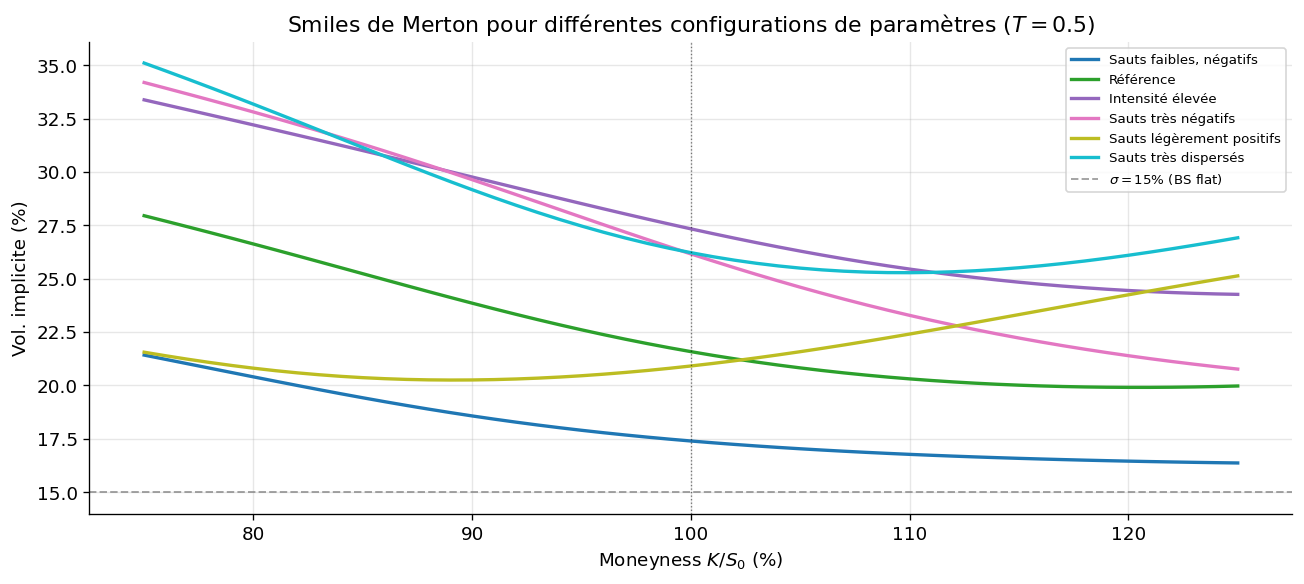


Tableau récapitulatif — Propriétés du smile ATM
                   Config   λ   μ_J    δ σ_imp ATM (%) Skew ATM Courbure ATM
  Sauts faibles, négatifs 0.5 -0.10 0.10         17.40    -8.55        55.03
                Référence 1.0 -0.10 0.15         21.58   -17.85       105.22
         Intensité élevée 2.0 -0.10 0.15         27.34   -22.45        57.09
      Sauts très négatifs 1.0 -0.20 0.15         26.16   -33.13        67.02
Sauts légèrement positifs 1.0  0.05 0.15         20.91    11.41        85.48
     Sauts très dispersés 1.0 -0.10 0.25         26.22   -19.77       212.21


In [8]:
# Tableau récapitulatif : paramètres et propriétés du smile ATM
T_tab = 0.5

configs = [
    {'lambda_': 0.5, 'mu_J': -0.10, 'delta': 0.10, 'label': 'Sauts faibles, négatifs'},
    {'lambda_': 1.0, 'mu_J': -0.10, 'delta': 0.15, 'label': 'Référence'},
    {'lambda_': 2.0, 'mu_J': -0.10, 'delta': 0.15, 'label': 'Intensité élevée'},
    {'lambda_': 1.0, 'mu_J': -0.20, 'delta': 0.15, 'label': 'Sauts très négatifs'},
    {'lambda_': 1.0, 'mu_J':  0.05, 'delta': 0.15, 'label': 'Sauts légèrement positifs'},
    {'lambda_': 1.0, 'mu_J': -0.10, 'delta': 0.25, 'label': 'Sauts très dispersés'},
]

fig, ax = plt.subplots(figsize=(11, 5))

colors_cfg = cm.tab10(np.linspace(0, 1, len(configs)))
rows_tab = []

for cfg, col in zip(configs, colors_cfg):
    smile = compute_smile(K_grid, T_tab, r, sigma,
                          cfg['lambda_'], cfg['mu_J'], cfg['delta'])
    ax.plot(moneyness_grid * 100, smile, '-', color=col, linewidth=2,
            label=cfg['label'])
    
    # Calcul skew et courbure ATM
    idx = np.argmin(np.abs(moneyness_grid - 1.0))
    atm_vol = smile[idx]
    skew_atm = (smile[idx+2] - smile[idx-2]) / (moneyness_grid[idx+2] - moneyness_grid[idx-2])
    curv_atm = (smile[idx+2] - 2*smile[idx] + smile[idx-2]) / (moneyness_grid[2] - moneyness_grid[0])**2
    rows_tab.append({
        'Config': cfg['label'],
        'λ': cfg['lambda_'],
        'μ_J': cfg['mu_J'],
        'δ': cfg['delta'],
        'σ_imp ATM (%)': f'{atm_vol:.2f}',
        'Skew ATM': f'{skew_atm:.2f}',
        'Courbure ATM': f'{curv_atm:.2f}',
    })

ax.axhline(sigma * 100, color='gray', linestyle='--', linewidth=1.2,
           alpha=0.7, label=f'$\\sigma={sigma*100:.0f}\\%$ (BS flat)')
ax.axvline(100, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Moneyness $K/S_0$ (%)')
ax.set_ylabel('Vol. implicite (%)')
ax.set_title(f'Smiles de Merton pour différentes configurations de paramètres ($T={T_tab}$)')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig('../figures/E3_comparaison_configs.png', dpi=150, bbox_inches='tight')
plt.show()

df_tab = pd.DataFrame(rows_tab)
print('\nTableau récapitulatif — Propriétés du smile ATM')
print(df_tab.to_string(index=False))

## Conclusion

L'expérience E3 confirme les propriétés qualitatives du smile de Merton :

1. **Hauteur** : l'intensité $\lambda$ détermine le niveau global du smile au-dessus de la
   volatilité diffusive $\sigma$. Pour $\lambda = 0$, on retrouve le smile plat de Black-Scholes.

2. **Largeur** : l'écart-type $\delta$ contrôle la courbure du smile. Un $\delta$ plus grand
   élargit le smile et augmente la convexité ATM.

3. **Asymétrie (skew)** : la moyenne des sauts $\mu_J$ contrôle l'inclinaison du smile.
   Des sauts négatifs dominants ($\mu_J < 0$) produisent un skew négatif, cohérent avec
   les observations empiriques sur les indices d'actions.

4. **Structure par terme** : le smile s'aplatit pour les longues maturités (conformément
   au théorème central limite appliqué aux sauts accumulés), ce qui est bien reproduit
   par le modèle.

Ces résultats sont cohérents avec les analyses de Cont & Tankov (2004, Ch. 11) et
justifient l'utilisation du modèle de Merton pour la modélisation du smile de volatilité.